In [2]:
# Created a random Dataset of 1000 rows

import pandas as pd
import numpy as np

np.random.seed(42) #make your random numbers reproducible.

n = 1000 # number of rows

df = pd.DataFrame({
    "user_id": range(1, n+1),
    "group": np.random.choice(["A", "B"], n),
    "device": np.random.choice(["Mobile", "Desktop"], n),
    "time_spent": np.random.normal(5, 2, n).round(2),
    "converted": np.random.binomial(1, 0.28, n)
}) # framing a data table

# Slightly better performance for B
df.loc[df['group'] == 'B', 'converted'] = np.random.binomial(1, 0.33, len(df[df['group']=='B']))

# Save file
df.to_csv("data/ab_test_data.csv", index=False)

print("Dataset created!")

Dataset created!


In [3]:
# Load and explore the data
import pandas as pd

df = pd.read_csv('data/ab_test_data.csv')
df.head()
df.info()
df.tail()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   user_id     1000 non-null   int64  
 1   group       1000 non-null   object 
 2   device      1000 non-null   object 
 3   time_spent  1000 non-null   float64
 4   converted   1000 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


,user_id,time_spent,converted
count,1000.000000,1000.000000,1000.000000
mean,500.500000,5.197810,0.290000
std,288.819436,1.977981,0.453989
min,1.000000,-0.840000,0.000000
25%,250.750000,3.870000,0.000000
50%,500.500000,5.165000,0.000000
75%,750.250000,6.480000,1.000000
max,1000.000000,11.390000,1.000000


In [4]:
# Data cleaning
import pandas as pd

df = pd.read_csv('data/ab_test_data.csv')

df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)

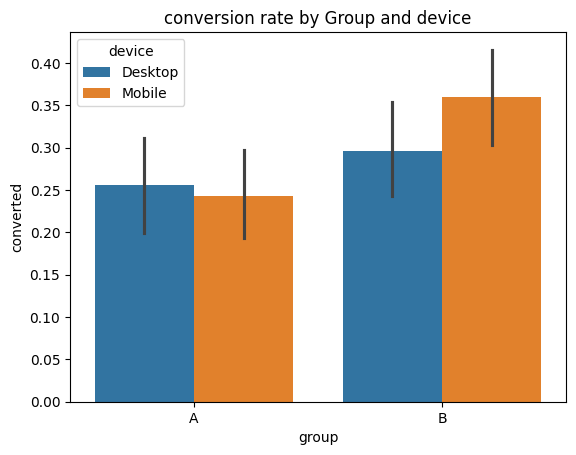

In [5]:
#EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/ab_test_data.csv')
#conversion rate
conversion_rate = df.groupby('group')['converted'].mean()
#segmentation
segmentation = df.groupby(['group','device'])['converted'].mean().unstack()
#visualization
sns.barplot(x='group', y='converted', hue='device', data=df)
plt.title("conversion rate by Group and device")
plt.show()

In [6]:
#Hypothesis Testing Z-Test
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('data/ab_test_data.csv')
#conversions
conversions = df.groupby('group')['converted'].sum()
#vistors
visitors = df.groupby('group')['converted'].count()

stat, p_value = proportions_ztest(conversions, visitors)

print("Z-stat:", stat)
print("P-value:", p_value)


Z-stat: -2.8021072645855596
P-value: 0.005076999007951959


In [16]:
#Uplift Calculation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('data/ab_test_data.csv')
#conversions
conversions = df.groupby('group')['converted'].sum()
#vistors
visitors = df.groupby('group')['converted'].count()

rate_A = conversions['A']/ visitors['A']
rate_B = conversions['B']/ visitors['B']

uplift = (((rate_B - rate_A)/rate_A) * 100).round(2)

print("Uplift Value: ",uplift)
print("Conversion: ",conversions)
print("visitor: ",visitors)

Uplift Value:  32.3
Conversion:  group
A    122
B    168
Name: converted, dtype: int64
visitor:  group
A    490
B    510
Name: converted, dtype: int64


In [27]:
#Confidence Interval
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

df = pd.read_csv('data/ab_test_data.csv')
conversions = df.groupby('group')['converted'].sum()
visitors = df.groupby('group')['converted'].count()

#confidence interval of grp A
ci_low_A, ci_high_A = sm.stats.proportion_confint(
    count = conversions['A'],
    nobs = visitors['A'],
    alpha = 0.05
)

#confidence interval of grp B
ci_low_B, ci_high_B = sm.stats.proportion_confint(
    count= conversions['B'], #number of users converted in B
    nobs= visitors['B'], # total users in B
    alpha = 0.05 #significance level Formula: confidence = 1 - alpha = 95%
)


print("ci_low_A: ",ci_low_A)
print("ci_high_A: ",ci_high_A)

print("ci_low_B: ",ci_low_B)
print("ci_high_B: ",ci_high_B)
#95% confident that the true conversion rate of group B lies between 28% and 37%.”


ci_low_A:  0.2106920225571154
ci_high_A:  0.287267161116354
ci_low_B:  0.2886211245773943
ci_high_B:  0.3702024048343704


INSIGHT:

1.) varient B has higher conversion rate than varient A with conversion rate for Var A being 24% and conversion rate for varB being 34%

2.) Uplift % is observed to be 32%

3.) p-value calculated to be 0.0050 which says, P-value is < 0.05 it is not statistically significant

4.)Desktop had good responce from group A and Mobile was a better responce from group B, In Total conversion rate for Mobile was responed very well by group B